# `Débruitage d'image avec ondelettes`
*Important:* (http://gpeyre.github.io/numerical-tours/installation_python/ ce notebook utilise les ondelettes pour réaliser un débruitage d’image non linéaire.

`Modèles de dégradation`
__Objectif__ : retrouver l’image « parfaite » à partir de ses versions dégradées

Plusieurs étapes sont nécessaires pour y arriver
- Définir un modèle mathématique qui relie l’image observée à l’image désirée (modèle direct)
- Trouver (estimer) les éventuels paramètres du modèles
- Inverser le modèle direct pour estimer l’image désirée


In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

### `Débruitage d'image`
On considère un modèle génératif simple d’images bruitées 
- $F = f_0+W$ où $f_0 \in \mathcal{R}^N$ est une image déterministe de $N$ pixels, 
- $W$ un bruit blanc gaussien distribué selon $\mathcal{N}(0,\sigma^2 \text{I}_N)$, 
- $\sigma^2$ est la variance du bruit.

L’objectif de cette méthode de débruitage est de : 
- définir un estimateur $\tilde F$ de $f_0$ qui ne dépend que de $F$, 
- c’est‑à‑dire $\tilde F = \phi(F)$ où $\phi : \mathcal{R}^N \rightarrow \mathcal{R}^N$ est une application potentiellement non linéaire.

On remarque que tandis que :
- $f_0$ est une image déterministe, 
- $F$ and $\tilde F$ sont toutes deux des variables aléatoires (d’où l’usage des lettres capitales).

Le but de ce débruitage est de réduire l’erreur, utilisant certaines connaissances a priori sur l’image (inconnue) $f_0$. 
- Une manière de mesurer cette erreur est de majorer le risque quadratique $\mathcal{E}_w(||{\tilde F - f_0}||^2)$, 
- où l’espérance est prise par rapport à la loi du bruit $W$.

#### `Chargement de l’image et ajout de bruit gaussien`
Chaque pixel aléatoire de $w$ selon une densité de probabilité Gaussienne est caractérisé par : $SNR =\Large \frac{\sigma^2{(f_0)}}{\sigma^2{(y)}}$
- dans le cas d'applications réelles, nous n’avons pas accès à l’image sous‑jacente $f_0$. 
- ici nous supposerons que: 
    - $f_0$ est connue, 
    - $f = f_0 + w\in \mathcal{R}^N$ est générée à partir d’une seule réalisation du bruit $w$ tirée de $W$. 
    - définissons l’image déterministe estimée par $\tilde f = \phi(f)$ qui est une réalisation du vecteur aléatoire $\tilde F$.
    - commençons par charger une image $f \in \mathcal{R}^N$ où $N=n \times n$ est le nombre de pixels.

In [2]:
n = 256
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)
print(f0.shape)
# normalise l'image, pour l’affichage et les paramètres (bruit, λ, etc.).
f0 = rescale(f0)

(256, 256)


In [3]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

Nous ajoutons un bruit Gaussian $w$ pour obtenir $f=f_0+w$ de variance $\sigma$.
 - Afficher l'image bruitée. 
 - Utiliser |clamp| pour saturer le résultat $[0,1]$ et éviter une perte du contraste à l'affichage.

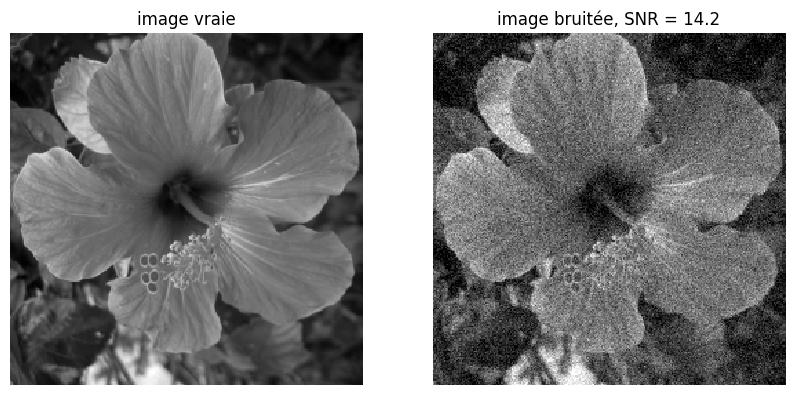

In [4]:
sigma = .08
y = f0 + np.random.randn(n, n)*sigma
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(y),f"image bruitée, SNR = {snr(f0,y):.3g}" , [1,2,2])

#### `Seuillage dur dans des bases d’ondelettes`
__`Un estimateur de débruitage non linéaire simple mais efficace s’obtient en`__ : 
- `seuillant les coefficients de` $f$ `dans une base orthogonale bien choisie` $\mathcal{B} = \{\psi_m\}_m$ de $\mathcal{R}^N$.
-  `en suite, nous nous concentrerons sur une base d’ondelettes, pour débruiter des images par morceaux régulières`.

L’opérateur de seuillage dur de seuil $T \geq 0$ appliqué à une image  $f$ est défini par :  
$$S_T^0(f)=\sum_{|\langle{f},{\psi_m}\rangle|>T}\langle{f},{\psi_m}\rangle\psi_m = \sum_m s_T^0(\langle{f},{\psi_m}\rangle)\psi_m$$
 - où l’opérateur de seuillage dur scalaire est is : $ S_T^0(\alpha) = \left\{ \begin{array}{ll}  \alpha  \text{ si } |\alpha| \ge T\\ 0 \text{ sinon } \end{array} \right.$
 - l’estimateur de débruitage est défini par : $ \tilde f = S_T^0(f)$


Fixer la valeur du seuil et afficher la fonction $s_T^0(\alpha)$.

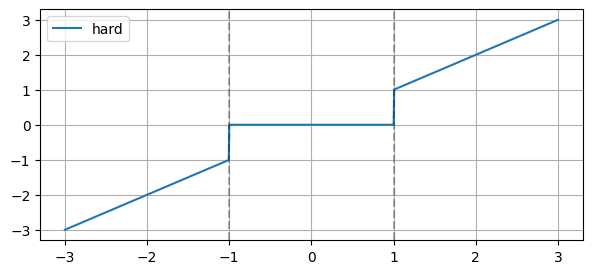

In [5]:
import numpy as np
import matplotlib.pyplot as plt

T = 1.0
alpha = np.linspace(-3, 3, 1000)

# Seuillage dur
hard = alpha * (np.abs(alpha) > T)

# Seuillage doux
# np.maximum : maximum élément par élément entre deux tableaux (ou tableau + scalaire).
soft = np.sign(alpha) * np.maximum(np.abs(alpha) - T, 0)

plt.figure(figsize=(7,3))
plt.plot(alpha, hard, label="hard")
plt.axvline(T, color="k", ls="--", alpha=0.3)
plt.axvline(-T, color="k", ls="--", alpha=0.3)
plt.axis("tight")
plt.grid(True)
plt.legend()
plt.show()

### `Principe Transformée en ondelette discrète (DWT)`
`Version “classique, décimée” de la DWT, par opposition aux variantes non décimées/invariantes par translation`
- passer le signal / image dans un filtre passe-bas et un filtre passe-haut, 
- sous-échantillonner (décimation),
- répèter sur la sous-bande basse pour construire la décomposition multi-échelle.
<p align="center">
  <img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/2_Wavelet Denoising /Image Denoising with Wavelets/images/DWT.png" alt="DWT" width="350">
</p>

- `Paramètres pour la transformation orthogonal en ondelettes.` 
- `Calculer premièrement les coefficients en ondelettes de l'image bruitée y.`

$(J)$ est le **niveau de décomposition maximal** (ou niveau de résolution le plus grossier) utilisé dans la DWT.
- On part du signal original au **niveau 0**.  
- Niveau $(j = 1)$ : 
  - on applique les filtres (passe-bas / passe-haut) + décimation, 
  - on obtient les détails $(cD_1)$ (les variations les plus fines) et une approximation $(cA_1)$.  
- Niveau $(j = 2)$ : 
  - on recommence sur l’approximation $(cA_1)$, 
  - on obtient $(cD_2)$ (détails un peu plus grossiers) et $(cA_2)$.  
- …  
- Niveau $(j = J)$ : on obtient $(cD_J)$ et $(cA_J)$, qui est l’approximation la plus **grossière** du signal.
$(J)$ :
- indique **combien de fois** on applique l’étape de filtrage + sous-échantillonnage,  
- fixe l’échelle de la partie la plus “lisse” $(cA_J)$ (support large $( \sim 2^J ))$,  
- et détermine combien de blocs de détails tu as : $(cD_1, \dots, cD_J)$.

### `Décomposition multiniveau`

In [6]:
import pywt
import numpy as np
# Transformée décimée (options.ti = 0)
# y    : signal ou image
# wavelet='dbN', 'symN', 'haar'
wavelet = 'sym8'  # par ex., à adapter à ce que fait options.wavelet
w = pywt.Wavelet(wavelet)
J = pywt.dwt_max_level(data_len=len(y), filter_len=w.dec_len)
print(f"nombre maximal de niveaux de décomposition : {J}")
# 2D image : f is 2D array
coeffs_ti_2d = pywt.wavedec2(y, wavelet=wavelet, level=J)
# reconstruction correspondante
y_rec_2d = pywt.waverec2(coeffs_ti_2d, wavelet=wavelet)

nombre maximal de niveaux de décomposition : 4


wavedec2 : retourne la liste ordonnée de tableaux de coefficients, 
- où `n`représente le niveau de décomposition. 
- le premier élément ( cA_n) du résultat est le tableau des coefficients d'approximation 
- les éléments suivants ( cD_n $\dots$ cD_1) sont les tableaux des coefficients de détail.

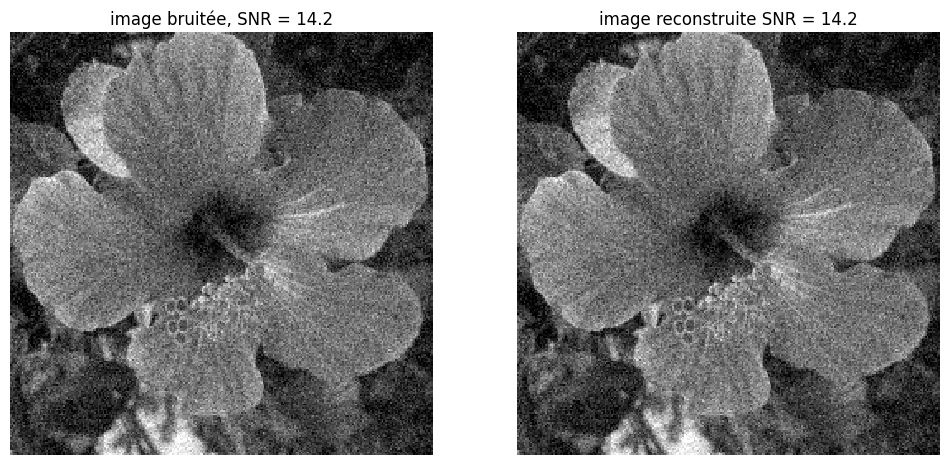

In [7]:
plt.figure(figsize=(12, 12))
imageplot(clamp(y),f"image bruitée, SNR = {snr(f0,y):.3g}" , [1,2,1])
imageplot(clamp(y_rec_2d),f"image reconstruite SNR = {snr(f0,y_rec_2d):.3g}",[1,2,2])

- Le SNR est (presque) le même car pour l’instant nous effectuons DWT → IDWT sans modification des coefficients. 
- C’est une transformée orthogonale/biorthogonale à reconstruction parfaite, donc $y_{rec}≈y$ à l’erreur numérique près.
- Choix du seuil T de type VisuShrink $T=\sigma \sqrt{2\log N}$ 

In [8]:
import numpy as np
import pywt

def estimate_sigma(detail_coeffs):
    # estimation robuste de σ à partir d'une sous-bande de détail
    # (MAD / 0.6745, classique Donoho-Johnstone)
    cH, cV, cD = detail_coeffs
    detail = np.concatenate([cH.ravel(), cV.ravel(), cD.ravel()])
    median = np.median(np.abs(detail))
    return median / 0.6745

def denoise_wavelet2D_visu(y, wavelet='sym13', J=3, mode='hard'):
    # décomposition
    coeffs = pywt.wavedec2(y, wavelet=wavelet, level=J)

    # estimation du bruit à partir du premier niveau de détails
    sigma = estimate_sigma(coeffs[-1])
    N = y.size
    T = sigma * np.sqrt(2 * np.log(N))  # seuil VisuShrink

    cA = coeffs[0]
    details = coeffs[1:]

    # seuillage sur toutes les sous-bandes de détails
    new_details = []
    for (cH, cV, cD) in details:
        cH_t = pywt.threshold(cH, T, mode=mode)
        cV_t = pywt.threshold(cV, T, mode=mode)
        cD_t = pywt.threshold(cD, T, mode=mode)
        new_details.append((cH_t, cV_t, cD_t))

    coeffs_thresh = [cA] + new_details
    y_rec = pywt.waverec2(coeffs_thresh, wavelet=wavelet)
    return y_rec, T, sigma, 

nombre maximal de niveaux de décomposition : 4, T : 0.3810, sigma : 0.0809


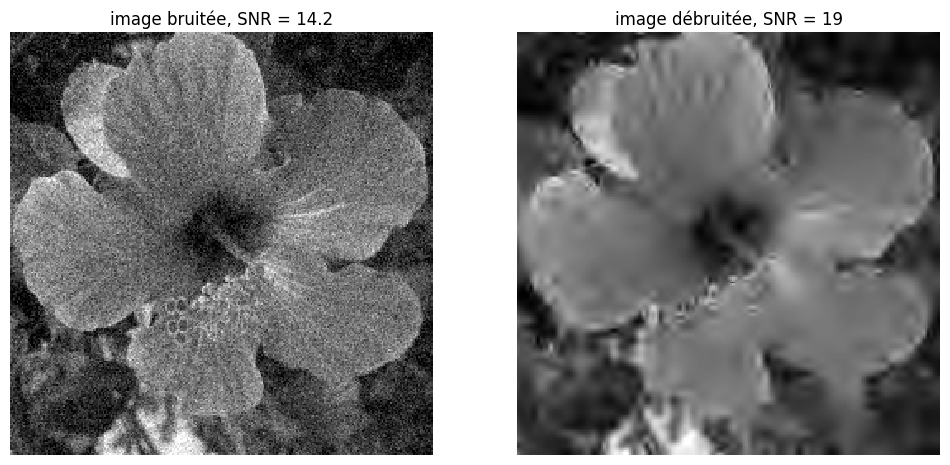

In [43]:
y_rec_2dhard, T, sigma = denoise_wavelet2D_visu(y, wavelet=wavelet, J=J, mode='hard')
print(f"nombre maximal de niveaux de décomposition : {J}, T : {T:.4f}, sigma : {sigma:.4f}")

plt.figure(figsize=(12, 12))
imageplot(clamp(y), f"image bruitée, SNR = {snr(f0, y):.3g}", [1, 2, 1])
imageplot(clamp(y_rec_2dhard), f"image débruitée, SNR = {snr(f0, y_rec_2dhard):.3g}", [1, 2, 2])
plt.show()

Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base (ondelettes et fonctions d’échelle).
`Ce que représente un coefficient`
Pour chaque échelle j et position k :
- $\phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle j et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

Mathématiquement, nous avons une décomposition du type : $f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$
- où $\phi_{J,k}$ sont les fonctions d’échelle et $\psi_{j,k}$ les ondelettes.
- le premier bloc que tu concatènes correspond à cA_J (approximation grossière).
- les blocs suivants sont cD_1, cD_2, ..., cD_J (détails de plus en plus grossiers suivant l'ordre).

_`Affichage des coefficients de débruitage :`_
La décimation, dans Discrete Wavelet Transform, est le fait de jeter un échantillon sur deux (ou plus généralement, un échantillon sur M pour un facteur de décimation M).
Pour un niveau de décomposition :
- On filtre le signal avec un passe-bas h → on obtient un signal “lissé”.
- On filtre avec un passe-haut g → on obtient un signal “détails”.
- Sur chacun des deux résultats, on ne garde qu’un échantillon sur deux :
   - $a_1[n]=(f∗h)[2n]$
   - $d_1[n]=(f∗g)[2n]$
_`Remarque :`_ 
- DWT “classique” (celle de wavedec) = filtrage + décimation → pas invariante par translation.
- Transformée stationnaire (SWT, swt) = filtrage sans décimation → invariance par translation, 
   - mais plus de coefficients (redondance).  

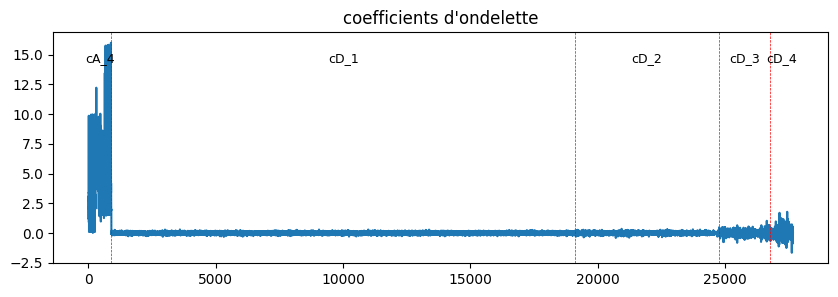

In [10]:
# Jmin : niveau minimal
# J    : niveau maximal ( J = Jmin + 1 )

coeffs_ti_2d = pywt.wavedec2(y, wavelet=wavelet, level=J)

cA_J = coeffs_ti_2d[0]
detail_tuples = coeffs_ti_2d[1:]        # [(cH_J, cV_J, cD_J), ..., (cH_1, cV_1, cD_1)]
detail_tuples = detail_tuples[::-1]     # du niveau 1 au niveau J

cDs = [t[2] for t in detail_tuples]     # ne garder que cD_j
blocs = [np.ravel(cA_J)] + [np.ravel(d) for d in cDs]

x = np.concatenate(blocs)
labels = [f"cA_{J}"] + [f"cD_{j}" for j in range(1, J+1)]

plt.figure(figsize=(10,3))
plt.plot(x)
plt.title("coefficients d'ondelette")

# positions de séparation + annotations
pos = 0

for b, lab in zip(blocs, labels):
    L = len(b)
    x_center = pos + L/2
    # ligne verticale au début du bloc (sauf le tout premier)
    if pos > 0:
        plt.axvline(pos, color='r', linestyle='--', linewidth=0.5)
    # texte au milieu du bloc
    plt.text(x_center, plt.ylim()[1]*0.9, lab, ha='center', va='top', fontsize=9, color='k')
    pos += L

plt.axis('tight')
plt.show()

Sur le graphe, nous voyons la concaténation des blocs $([cA_J, cD_1, cD_2, \dots, cD_J])$ :
- `CA_4` : **coefficients d’approximation** très “énergétique” (contenu lisse à grande échelle).  
- Chaque zone séparée par une ligne verticale rouge correspond à une **bande de détails** $(cD_j)$ 
__à une échelle donnée__ : 
- plus on va vers la droite, plus l’échelle est **grossière** (variations plus larges).  
- La partie centrale “plate” proche de 0, avec beaucoup de petites oscillations, montre que la plupart des coefficients sont petits (souvent assimilables à du bruit), ce qui justifie le seuillage pour le débruitage.

In [11]:
import matplotlib.pyplot as plt

def plot_wavelet_2d(coeffs):
    """
    coeffs : [cA_J, (cH_J, cV_J, cD_J), ..., (cH_1, cV_1, cD_1)]
    comme renvoyé par pywt.wavedec2
    """
    cA_J = coeffs[0]
    details = coeffs[1:]  # liste de tuples (cH_j, cV_j, cD_j)

    n_levels = len(details)

    fig, axes = plt.subplots(n_levels + 1, 4, figsize=(10, 2.5*(n_levels+1)))
    # première ligne : approximation
    ax = axes[0, 0]
    im = ax.imshow(cA_J, cmap="gray")
    ax.set_title("cA_J")
    ax.axis("off")
    for j in range(1, 4):
        axes[0, j].axis("off")

    # lignes suivantes : détails par niveau
    for i, (cH, cV, cD) in enumerate(details, start=1):
        for ax, img, title in zip(axes[i], [cH, cV, cD, None],
                                  ["cH", "cV", "cD", ""]):
            ax.axis("off")
            if img is not None:
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{title}_{n_levels-i+1}")

    plt.tight_layout()
    return fig


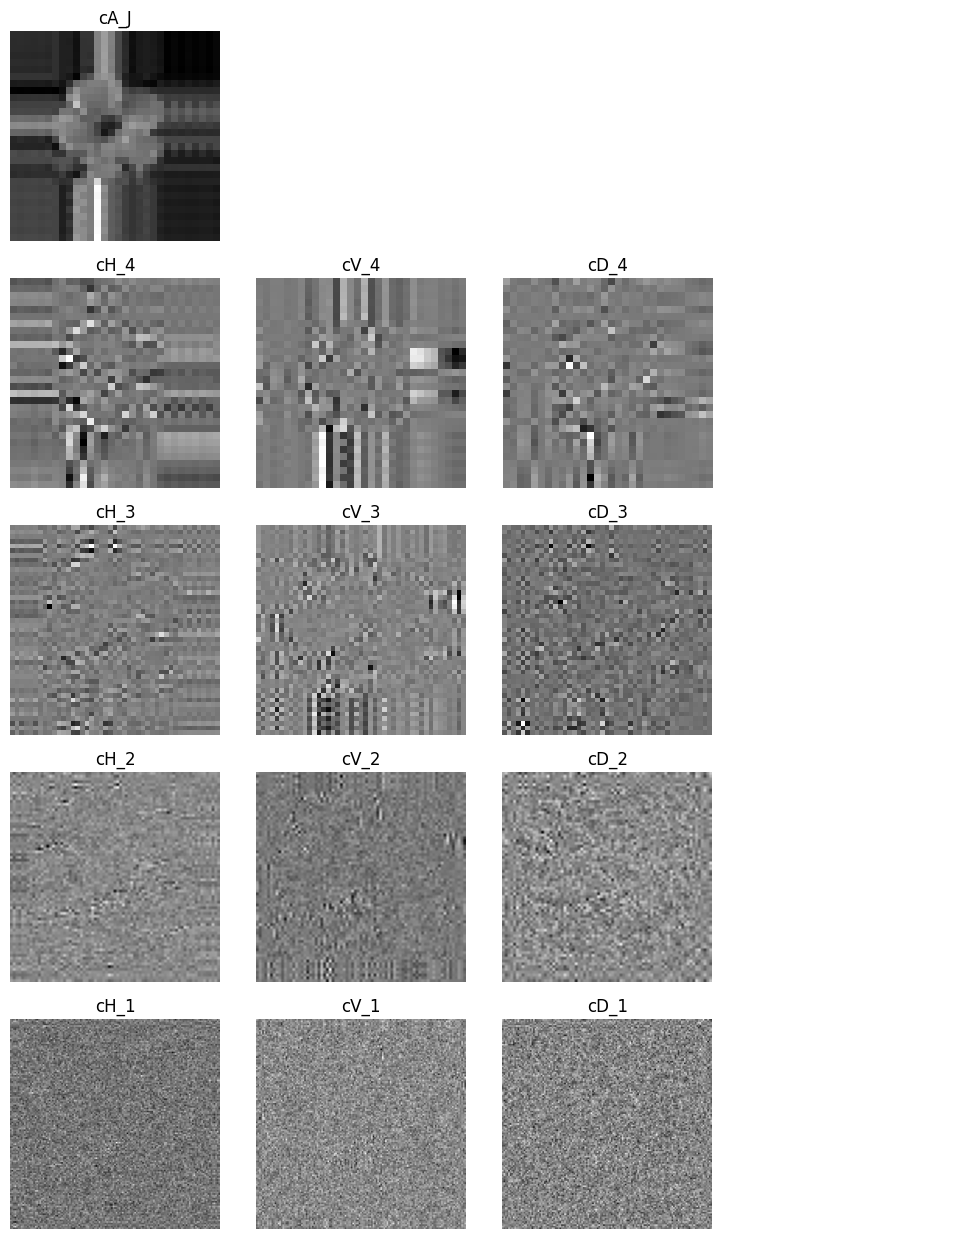

In [12]:
coeffs2 = pywt.wavedec2(y, wavelet=wavelet, level=J)
plot_wavelet_2d(coeffs2)
plt.show()

Choisir la valeur de seuil, qui devrait être proportionnelle au niveau de bruit $\sigma$.

In [13]:
T = 3*sigma

Seuillage dur des coefficients en dessous du niveau de bruit pour obtenir $a_T(m)=s_T^0(a_m)$.

### `Seuillage dur dans une base d’ondelettes`
#### __Un estimateur de débruitage non linéaire simple mais efficace s’obtient en__ : 
`1°) Seuillant les coefficients de` $f$ `dans une base orthogonale bien choisie` $\mathcal{B} = \{\psi_m\}_m$ de $\mathcal{R}^N$, 
- base choisie de façon à fournir une représentation parcimonieuse du signal 
- quelques coefficients seulement portent l’essentiel de l’information, le bruit est réparti sur l’ensemble des coefficients.

`2°) On applique ensuite un seuillage (dur ou doux) à ces coefficients`, 
- en annulant ceux dont la magnitude est inférieure à un certain seuil lié au niveau de bruit, 
- puis on reconstruit un estimateur débruité en revenant dans le domaine spatial.  

`3°) Se placer dans une base adaptée au débruitage d’images par morceaux et représenter de façon parcimonieuse` :  
- les contours,
- les structures géométriques,
- en répartissant le bruit sur l’ensemble des échelles

L’opérateur de seuillage dur de seuil $T \geq 0$ appliqué à une image  $f$ est défini par :  
$$S_T^0(f)=\sum_{|\langle{f},{\psi_m}\rangle|>T}\langle{f},{\psi_m}\rangle\psi_m = \sum_m s_T^0(\langle{f},{\psi_m}\rangle)\psi_m$$
 - où l’opérateur de seuillage dur scalaire est is : $ S_T^0(\alpha) = \left\{ \begin{array}{ll}  \alpha  \text{ si } |\alpha| \ge T\\ 0 \text{ sinon } \end{array} \right.$
 - l’estimateur de débruitage est défini par : $ \tilde f = S_T^0(f)$
 - $\large \alpha$ désigne un coefficient de $f$ dans la base $\mathcal{B}={\psi_m}_m$



In [14]:
import pywt
import numpy as np

coeffs2 = pywt.wavedec2(y, wavelet=wavelet, level=J)

cA = coeffs2[0]
details = coeffs2[1:]

def hard_thresh(arr, T):
    return arr * (np.abs(arr) > T)

details_T = []
for (cH, cV, cD) in details:
    cH_T = hard_thresh(cH, T)
    cV_T = hard_thresh(cV, T)
    cD_T = hard_thresh(cD, T)
    details_T.append((cH_T, cV_T, cD_T))

Display the thresholded coefficients.

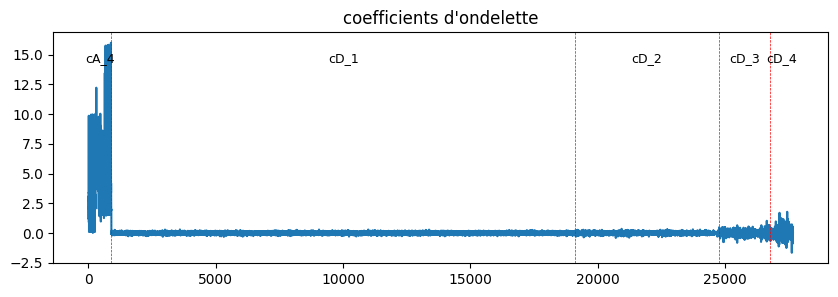

In [15]:
# Jmin : niveau minimal
# J    : niveau maximal ( J = Jmin + 1 )

cA_J = coeffs2[0]
detail_tuples = coeffs2[1:]        # [(cH_J, cV_J, cD_J), ..., (cH_1, cV_1, cD_1)]
detail_tuples = detail_tuples[::-1]     # du niveau 1 au niveau J

cDs = [t[2] for t in detail_tuples]     # ne garder que cD_j
blocs = [np.ravel(cA_J)] + [np.ravel(d) for d in cDs]

x = np.concatenate(blocs)
labels = [f"cA_{J}"] + [f"cD_{j}" for j in range(1, J+1)]

plt.figure(figsize=(10,3))
plt.plot(x)
plt.title("coefficients d'ondelette")

# positions de séparation + annotations
pos = 0

for b, lab in zip(blocs, labels):
    L = len(b)
    x_center = pos + L/2
    # ligne verticale au début du bloc (sauf le tout premier)
    if pos > 0:
        plt.axvline(pos, color='r', linestyle='--', linewidth=0.5)
    # texte au milieu du bloc
    plt.text(x_center, plt.ylim()[1]*0.9, lab, ha='center', va='top', fontsize=9, color='k')
    pos += L

plt.axis('tight')
plt.show()

Reconstruire l'image $\tilde f$ à partir des coefficients bruités.

In [16]:
coeffs2_T = [cA] + details_T
y_rec = pywt.waverec2(coeffs2_T, wavelet=wavelet)

Afficher le résultat débruité.

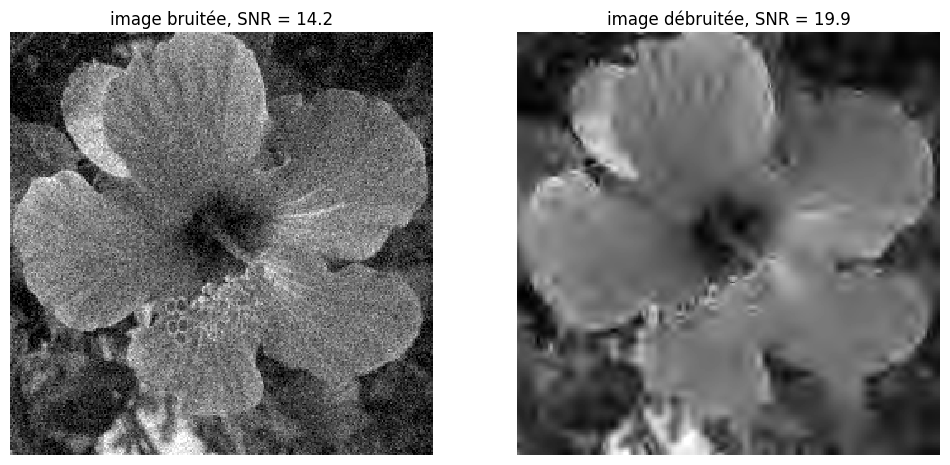

In [17]:
plt.figure(figsize=(12, 12))
imageplot(clamp(y), f"image bruitée, SNR = {snr(f0, y):.3g}", [1, 2, 1])
imageplot(clamp(y_rec_2d), f"image débruitée, SNR = {snr(f0, y_rec):.3g}", [1, 2, 2])
plt.show()

### `Débruitage par ondelette avec un seuillage soft`

L'image estimée $\tilde f$ utilisant un seuillage dur souffre de plusieurs artéfacts, il est possible d'améliorer le résultat en utilisant un seuillage soft défini comme :

$ S_T^0(\alpha) = \left\{ \begin{array}{ll}  \alpha  \text{ si } |\alpha| \ge T\\ 0 \text{ sinon } \end{array} \right.$

 - $ \tilde f = S_T^1(f) = \sum_m s_T^1(\langle{f}{\psi_m}\rangle) \psi_m \text{\dots }\text{où } s_T^1(\alpha) = \max({0, 1 - \frac{T}{|\alpha|}})\alpha$

Afficher le seuillage soft $s_T^1(\alpha)$.

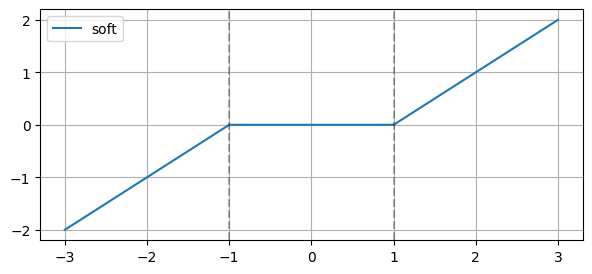

In [18]:
import numpy as np
import matplotlib.pyplot as plt

T = 1.0
alpha = np.linspace(-3, 3, 1000)

# Seuillage dur
hard = alpha * (np.abs(alpha) > T)

# Seuillage doux
# np.maximum : maximum élément par élément entre deux tableaux (ou tableau + scalaire).
soft = np.sign(alpha) * np.maximum(np.abs(alpha) - T, 0)

plt.figure(figsize=(7,3))
plt.plot(alpha, soft, label="soft")
plt.axvline(T, color="k", ls="--", alpha=0.3)
plt.axvline(-T, color="k", ls="--", alpha=0.3)
plt.axis("tight")
plt.grid(True)
plt.legend()
plt.show()

Effectuer le seuillage soft

nombre maximal de niveaux de décomposition : 4, T : 0.3810, sigma : 0.0809


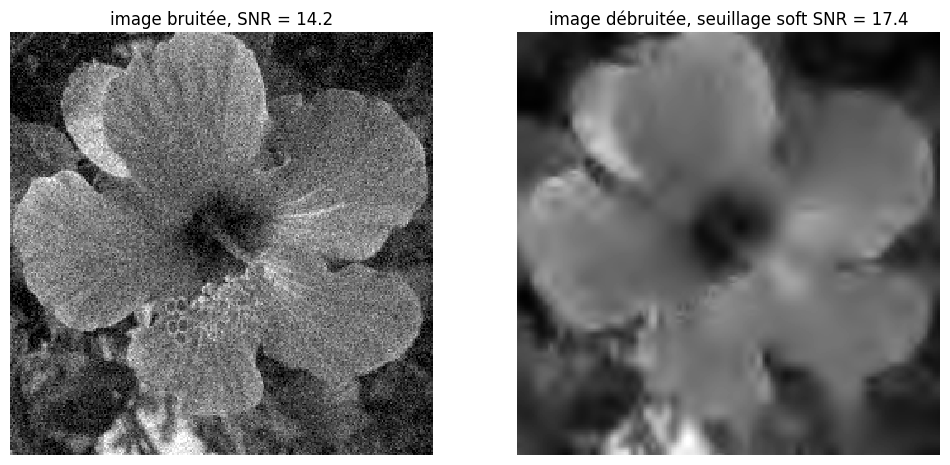

In [19]:
# Définir le niveau de seuillage
T = 3/ 2*sigma
y_rec_2d, T, sigma = denoise_wavelet2D_visu(y, wavelet=wavelet, J=J, mode='soft')
print(f"nombre maximal de niveaux de décomposition : {J}, T : {T:.4f}, sigma : {sigma:.4f}")

plt.figure(figsize=(12, 12))
imageplot(clamp(y), f"image bruitée, SNR = {snr(f0, y):.3g}", [1, 2, 1])
imageplot(clamp(y_rec_2d), f"image débruitée, seuillage soft SNR = {snr(f0, y_rec_2d):.3g}", [1, 2, 2])
plt.show()

Pour légèrement améliorer la performance du seuillage doux on ne seuille pas les coefficients correspondants de grand échelle (gros détails) des ondelettes.

- Reconstruire estimateur de seuillage doux  $\tilde f$.
- Afficher le résultat du débruitage par ondellettes avec seuillage doux.

In [20]:
import pywt
import numpy as np

def denoise_wavelet_soft_nocoarse(y, wavelet, level, T):
    # Décomposition 2D
    coeffs = pywt.wavedec2(y, wavelet=wavelet, level=level)
    cA, detail_coeffs = coeffs[0], coeffs[1:]   # cA : coarse scale (approx)

    def soft(x, T):
        return np.sign(x) * np.maximum(np.abs(x) - T, 0)

    # On laisse cA intact, on seuillle uniquement les détails
    detail_thresh = []
    for (cH, cV, cD) in detail_coeffs:
        cH_t = soft(cH, T)
        cV_t = soft(cV, T)
        cD_t = soft(cD, T)
        detail_thresh.append((cH_t, cV_t, cD_t))

    coeffs_thresh = [cA] + detail_thresh
    y_rec = pywt.waverec2(coeffs_thresh, wavelet=wavelet)

    return y_rec

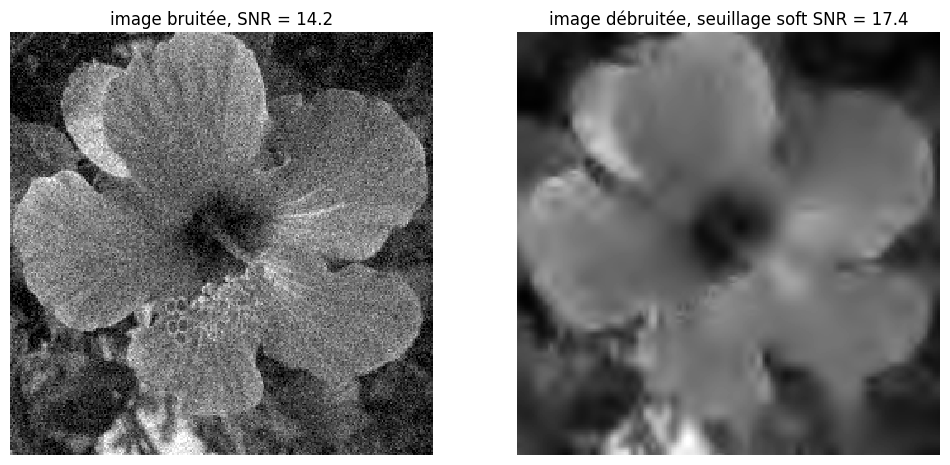

In [21]:
y_rec = denoise_wavelet_soft_nocoarse(y, wavelet, J-1, T)

plt.figure(figsize=(12, 12))
imageplot(clamp(y), f"image bruitée, SNR = {snr(f0, y):.3g}", [1, 2, 1])
imageplot(clamp(y_rec_2d), f"image débruitée, seuillage soft SNR = {snr(f0, y_rec_2d):.3g}", [1, 2, 2])
plt.show()

On peut montrer que si l’erreur d’approximation non linéaire $ ||f_0-S_T(f_0)||^2 $ décroît rapidement vers zéro lorsque le seuil $T$ diminue, alors le risque quadratique $ \mathcal{E_w}( ||f-S_T(f)||^2 ) $ décroît lui aussi rapidement vers zéro lorsque l’écart type du bruit $\sigma$ diminue. Pour que ce résultat soit valable, il est nécessaire de choisir la valeur du seuil selon la règle du seuil universel $ T = \sigma \sqrt{2\log(N)}$

Si l’erreur d’approximation non linéaire  $\|f_0 - S_T(f_0)\|^2$ diminue rapidement lorsque le seuil $T$ décroît, cela signifie que le signal propre $f_0$ admet une représentation parcimonieuse dans la base considérée (peu de gros coefficients, beaucoup de petits). 

Dans ce cas, on peut montrer que le **risque quadratique moyen** $\mathcal{E_w}\bigl(\|f - S_T(f)\|^2\bigr)$ décroît lui aussi rapidement quand le niveau de bruit $\sigma$ tend vers zéro. 

Pour obtenir ce résultat de manière générale (au sens minimax), on choisit le seuil selon la **règle universelle** $T = \sigma\sqrt{2\log N},$ qui garantit que, avec une probabilité élevée, les coefficients dus uniquement au bruit sont inférieurs à $T$, tandis que les vrais coefficients du signal, plus grands, sont conservés.  

Tu veux aussi la version un peu plus détaillée avec l’argument probabiliste sur le maximum d’un vecteur gaussien $w \sim \mathcal N(0,\sigma^2 I_N)$ ?

__Exercise 1__

Determiner la meilleure valeur de seuil $T$ for pour le seuillage dur et doux.
Tester plusieurs valeurs de $T$ dans $[.8*\sigma, 4.5\sigma]$, et afficher les valeurs de SNR 
- $SNR = \frac{\sigma^2{(f_0)}}{\sigma^2{(y)}} = 10\log_{10}(\large \frac{||f_0||_2^2 }{||f_0-\tilde f||_2^2})$

Que pouvons nous conclure de ces résultats ?
Tester avec une autre image ?

In [22]:
def denoise_wavelet2D(y, T, wavelet='sym13', J=3, mode='hard'):
    # décomposition
    coeffs = pywt.wavedec2(y, wavelet=wavelet, level=J)

    cA = coeffs[0]
    details = coeffs[1:]
    # seuillage sur toutes les sous-bandes de détails
    new_details = []
    for (cH, cV, cD) in details:

        cH_t = pywt.threshold(cH, T, mode=mode)
        cV_t = pywt.threshold(cV, T, mode=mode)
        cD_t = pywt.threshold(cD, T, mode=mode)
        new_details.append((cH_t, cV_t, cD_t))

    coeffs_thresh = [cA] + new_details
    y_rec = pywt.waverec2(coeffs_thresh, wavelet=wavelet)
    return y_rec

T* hard : 0.258 SNR = 20.359
T* soft : 0.125  SNR = 20.994


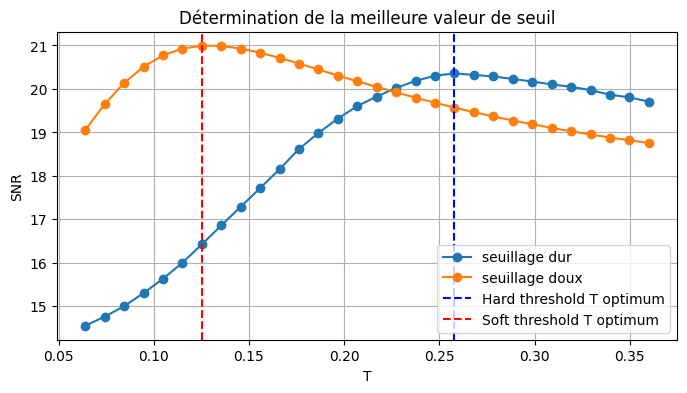

In [32]:
import numpy as np
import matplotlib.pyplot as plt

val_sigma=.08
T_list = np.linspace((val_sigma*.8), (val_sigma*4.5), 30)   
snr_hard = []
snr_soft = []

for T in T_list:

    y_rec_hard = denoise_wavelet2D(y, T, wavelet='sym13', J=3, mode='hard')
    y_rec_soft = denoise_wavelet2D(y, T, wavelet='sym13', J=3, mode='soft')   

    snr_hard.append(snr(f0, y_rec_hard))
    snr_soft.append(snr(f0, y_rec_soft))

idx_h = np.argmax(snr_hard)
idx_s = np.argmax(snr_soft)

T_opt_hard = T_list[idx_h]
T_opt_soft = T_list[idx_s]

print(f"T* hard : {T_opt_hard:.3f} SNR = {snr_hard[idx_h]:.3f}")
print(f"T* soft : {T_opt_soft:.3f}  SNR = {snr_soft[idx_s]:.3f}")    

plt.figure(figsize=(8, 4))
plt.plot(T_list, snr_hard, '-o', label=r'seuillage dur')
plt.plot(T_list, snr_soft, '-o', label=r'seuillage doux')
plt.axvline(T_opt_hard, color='b', linestyle='--', label=r'Hard threshold T optimum')
plt.axvline(T_opt_soft, color='r', linestyle='--', label=r'Soft threshold T optimum')
plt.xlabel(r'T')
plt.ylabel('SNR')
plt.title('Détermination de la meilleure valeur de seuil')
plt.grid(True)
plt.legend()
plt.show()

`La courbe est cohérente et raconte quelque chose de très classique :`
- Soft : le SNR augmente vite avec T, atteignant un plateau vers T≈0.125, puis se stabilise au‑dessus de 21dB.
- Hard : montée plus lente, SNR reste en dessous du soft pour les petits seuils, puis rattrape vers T≈0.26.
`Au final, sur toute la plage de seuils testée :` 
- le soft est meilleur ou égal au hard, 
- un optimum un peu plus bas en T, 
- c'est est exactement ce qu’on attend théoriquement 
- pour le seuillage doux (moins d’artefacts, meilleure adaptation).

### `Débruitage invariant par translation avec cycle spinning`
_`Les transformées en ondelettes orthogonales ne sont pas invariantes par translation`_. 
 - $=>$ le traitement d’une image et celui d’une version translatée donnent des résultats différents.

__`On peut transformer n’importe quel débruiteur en un débruiteur invariant par translation en utilisant la technique de cycle spinning`__. 
- le débruiteur est appliqué à plusieurs copies translatées de l’image, 
- puis les images débruitées obtenues sont re‑translatées à leur position d’origine, 
- et enfin les résultats sont moyennés.
- cela revient à définir l’estimateur : $\large \tilde f = \frac{1}{M} \sum_{i=1}^{M} T_{-\delta_i} \circ S_T(f) \circ T_{\delta_i}$
  - où $S_T$ désigne le seuillage (dur ou doux),
  - $T_{\delta}(f)(x)=f(x−{\delta})$ est l’opérateur de translation, en utilisant des conditions aux bords périodiques.
  - ici, $(\delta_i)_i$ est un ensemble de M translations discrètes.

Une invariance parfaite serait obtenue en utilisant toutes les N translations possibles, mais en pratique on se contente d’un petit nombre $M ≪ N$ de translations pour obtenir une invariance approchée. 

On choisit un nombre $m$ de translations dans chaque direction, de sorte que $M = m^2$

In [36]:
# Générer un ensemble de translations (delta_i)_i.
m = 4
dY, dX = np.meshgrid(np.arange(m), np.arange(m))
delta = np.column_stack((dX.ravel(), dY.ravel()))

Donc les couples $(dX.ravel(),dY.ravel()) \text{ : } (0,0),(0,1),(0,2),(0,3),(1,0),(1,1),…,(3,3)$ servent à construire la liste des translations $\delta_i$  utilisées pour le cycle spinning, c’est‑à‑dire : 
- toutes les translations possibles $(\delta_x,\delta_y) \text{ avec } \delta_x,\delta_y \in\{0,\dots,m−1\}$
Pour éviter de stocker toutes les versions translatées en mémoire, effectue une moyenne progressive des traductions en posant : 
 - $f(0) = f^{(0)} = 0$ puis en définissant, 
 - pour $i=1,\dots,M=1,…,M$, une relation de récurrence de la forme suivante.

   - $\large \forall, i=1,\ldots,M, f^{(i)} = (1-\frac{i}{n})    f^{(i-1)} + \frac{i}{n} T_{-\delta_i} \circ S_T(f) \circ T_{\delta_i}$
 - nous avons alors $\tilde f = f^{(M)}$ après $M$ étapes.

### `1. Cycle spinning`
On part d’un débruiteur quelconque $S_T$ (le seuillage en ondelettes), pour construire un débruiteur invariant par translation.

Pour ça, on fait :
- on prend l’image bruitée f.
- on la translate (décalage circulaire) de plusieurs vecteurs $\delta_i$
$$ \tilde f = \frac{1}{M} \sum_{i=1}^{M} T_{-\delta_i} \circ S_T(f) \circ T_{\delta_i}$$
Pour chaque translation $\delta_i$ on :
- __translate__,décale circulairement l’image bruitée de $\delta_i$ : $f : f_{\delta_i}= T_{\delta_i}(f)$ ;
- __débruite__, applique le même débruiteur à cette version translatée : $g_{\delta_i} = S_T(f_{\delta_i})$;
- __retablir l’image__, remet l’image débruitée à sa position d’origine: $h_{\delta_i}=T_{-\delta_i}(g_{\delta_i})$
- __moyenne toutes ces images remises en place__ : $\hat f = \frac{1}{M} \sum_{i=1}^M h_{\delta_i}$

In [55]:
def cycle_spinning_denoise2D(y, sigma, wavelet='sym13', level=3, mode='soft', m=4):
    """
    Débruitage TI (cycle spinning) :
    - y : image bruitée 2D (numpy array)
    - sigma : écart-type du bruit (pour le seuil universel)
    - wavelet, level, mode : paramètres de débruitage
    - m : nombre de translations par direction (M = m^2)
    """
    n0, n1 = y.shape
    # seuil universel
    N = n0 * n1
    T = sigma * np.sqrt(2 * np.log(N))

    # accumulateur de la moyenne TI
    fTI = np.zeros_like(y, dtype=float)

    # générer les translations discrètes (dx, dy)
    dY, dX = np.meshgrid(np.arange(m), np.arange(m))
    delta = np.column_stack((dX.ravel(), dY.ravel()))  # shape (M, 2)
    M = delta.shape[0]

    for i in range(M):
        dx, dy = delta[i]
        # 1) translation circulaire de l'image bruitée
        fS = np.roll(y, shift=(dx, dy), axis=(0, 1))
        # 2) débruitage (ondelettes + seuillage)
        fS_d = denoise_wavelet2D(fS, T, wavelet=wavelet, J=level, mode=mode)
        # 3) translation inverse
        fS_back = np.roll(fS_d, shift=(-dx, -dy), axis=(0, 1))
        # 4) moyenne progressive : fTI = moyenne des i+1 premières images
        k = i + 1
        fTI = (k - 1) / k * fTI + 1 / k * fS_back

    return fTI, T

In [56]:
# y : image bruitée (float32 ou float64, normalisée sur [0,1] par ex.)
sigma = .8          # ou estimation du bruit
f_tisoft, T = cycle_spinning_denoise2D(y, sigma, wavelet='sym13', level=3,mode='soft',m=4)
f_tihard, T = cycle_spinning_denoise2D(y, sigma, wavelet='sym13', level=3,mode='hard',m=4)
print("Seuil utilisé :", T)

Seuil utilisé : 3.767712072049519


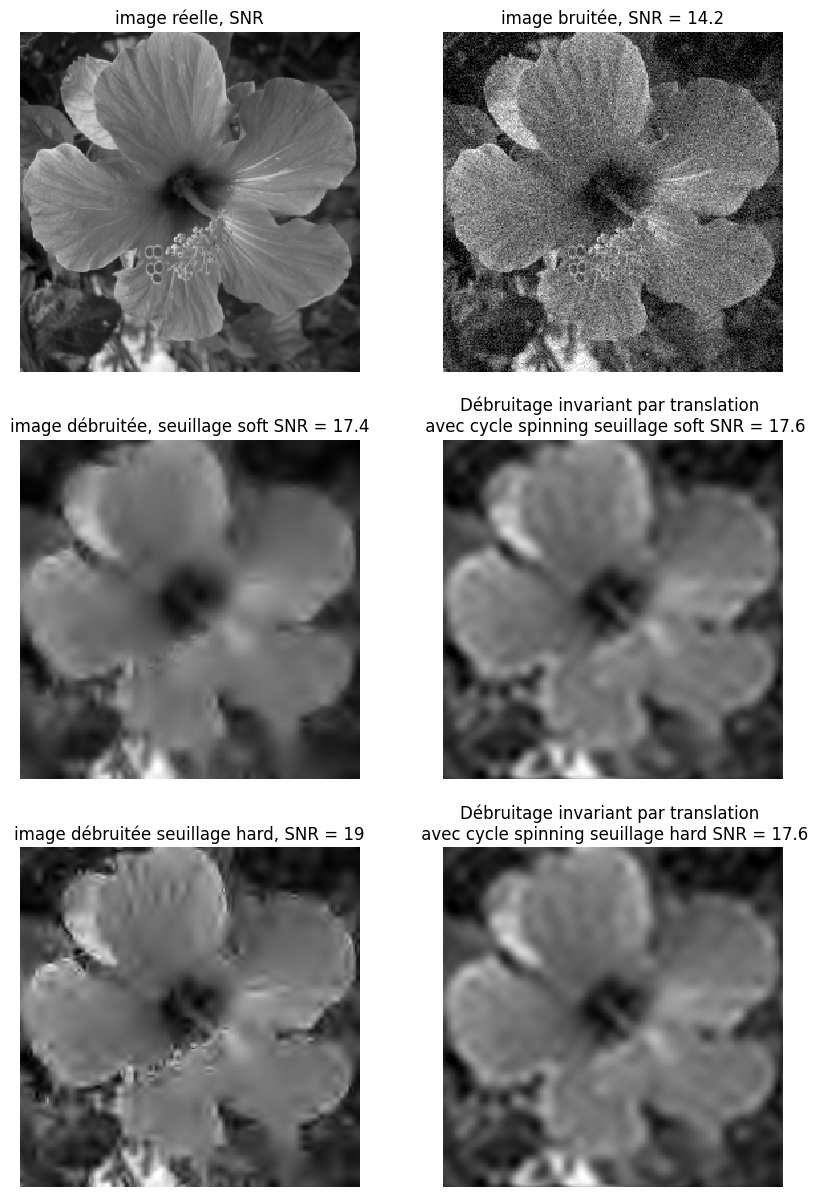

In [59]:
plt.figure(figsize=(10, 15))
imageplot(clamp(f0),f"image réelle, SNR", [3, 2, 1])
imageplot(clamp(y), f"image bruitée, SNR = {snr(f0, y):.3g}", [3, 2, 2])
imageplot(clamp(y_rec_2d), f"image débruitée, seuillage soft SNR = {snr(f0, y_rec_2d):.3g}", [3, 2, 3])
imageplot(clamp(f_tisoft), f"Débruitage invariant par translation \n avec cycle spinning seuillage soft SNR = {snr(f0, f_tisoft):.3g}", [3, 2, 4])
imageplot(clamp(y_rec_2dhard), f"image débruitée seuillage hard, SNR = {snr(f0, y_rec_2dhard):.3g}", [3, 2, 5])
imageplot(clamp(f_tihard), f"Débruitage invariant par translation \n avec cycle spinning seuillage hard SNR = {snr(f0, f_tihard):.3g}", [3, 2, 6])

plt.show()

À droite : image débruitée par seuillage soft + cycle spinning, SNR ≈ 17.6 dB. 
Le bruit de haute fréquence est fortement réduit, les grandes structures de la fleur sont lissées mais bien visibles. On gagne donc environ 3.4 dB de SNR par rapport à l’image bruitée, et l’aspect visuel est cohérent :
 - moins de grain,
 - contours et grandes formes préservés,
 - textures fines un peu lissées (classique avec un seuillage soft assez fort).

__Exercise 2__

Perform the cycle spinning denoising by iterating on $i$.

In [28]:
solutions.exo2()

NameError: name 'solutions' is not defined

In [ ]:
## Insert your code here.

__Exercise 3__

Study the influence of the number $m$ of shift on the denoising
quality.

In [ ]:
solutions.exo3()

In [ ]:
## Insert your code here.

Translation Invariant Wavelet Transform
---------------------------------------
Another way to achieve translation invariance, which is equivalent to
performing cycle spinning, is to replace the orthogonal wavelet
basis $\Bb = \{\psi_m\}_{m=0}^{N-1}$ by a redundant translation
invariant wavelet frame
$$ \Dd = \enscond{ \psi_m(\cdot-\de) }{ m = 0,\ldots,N-1, \de \in \{0,\ldots,n-1\}^2 }. $$


One can prove that there is actually only $P = N\log_2(N)$ atoms in this
dictionary, that we note $\De = \{\tilde \psi_k\}_{k=0}^{P-1}$.


One can furthermore define weights $\la_k>0$ so that the
following reconstruction formula holds (pseudo-invers reconstruction)
$$ f = \sum_k \la_k \dotp{f}{\tilde \psi_k} \tilde \psi_k. $$


For Scilab, we need to extend a little the available memory.


_Important:_ If you are using an old version (<v5)
of Scilab, then use |extend_stack_size(4,1)| instead.

In [ ]:
extend_stack_size(4)

The invariant transform is obtained using the same function, by
activating the switch |options.ti=1|.

In [ ]:
options.ti = 1
a = perform_wavelet_transf(f0, Jmin, + 1, options)

|a(:,:,1)| corresponds to the low scale residual.
Each |a(:,:,3*j+k+1)| for k=1:3 (orientation) corresponds to a scale of wavelet coefficient, and has
the same size as the original image.

In [ ]:
i = 0
for j in 1: 2:
for k in 1: 3:
        i = i + 1
        imageplot(a(: , : , i + 1), strcat(['Scale = ' num2str(j) ' Orientation = ' num2str(k)]), 2, 3, i)

Translation Invariant Wavelet Denoising
---------------------------------------
A translation invariant thresholding estimator is defined as
$$ \tilde f = \sum_k \la_k s_T(\dotp{f}{\tilde \psi_k}) \tilde \psi_k, $$
where $s_T$ is either the soft or the hard thresholding mapping.


This estimator is equal to the cycle spinning estimator when using the
full set $M=N$ of translates. It is however much faster to compute
because computing the whole set of $N\log_2(N)$ inner products $(\dotp{f}{\tilde\psi_k})_k$
is obtained with the fast a trou algorithm in $O(N\log_2(N))$
operations.
Similarely, a fast inverse transform with the same complexity allows one
to reconstruct $\tilde f$ from the set of thresholded coefficients.


First we compute the translation invariant wavelet transform

In [ ]:
options.ti = 1
a = perform_wavelet_transf(f, Jmin, + 1, options)

Then we threshold the set of coefficients.

In [ ]:
T = 3.5*sigma
aT = perform_thresholding(a, T, 'hard')

Display noisy wavelets coefficients at a given fixed scale.

In [ ]:
J = size(a, 3)-5

imageplot(a(: , : , J), 'Noisy coefficients')

Display thresholded wavelets coefficients

In [ ]:
imageplot(aT(: , : , J), 'Thresholded coefficients')

We can now reconstruct

In [ ]:
fTI = perform_wavelet_transf(aT, Jmin, -1, options)

Display the denoising result $\tilde f$.

In [ ]:
imageplot(clamp(fTI), strcat(['Hard invariant, SNR = ' num2str(snr(f0, fTI), 3)]))

__Exercise 4__

Determine the best threshold $T$ for both hard and soft thresholding,
but now in the translation invariant case. What can you conclude ?

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.